A Simple Chatbot Using LangGraph

In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END

#reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [5]:
#Defining State Schema
class State(TypedDict):
    messages: Annotated[list, add_messages]

#import the env
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

from langchain_groq import ChatGroq


In [8]:
llm_groq=ChatGroq(model="openai/gpt-oss-120b")
llm_groq.invoke("hello my name is onkar")

AIMessage(content='Hello Onkar! Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "hello my name is onkar". Likely they are greeting. The assistant should respond politely, perhaps ask how can help. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 77, 'total_tokens': 136, 'completion_time': 0.122726167, 'completion_tokens_details': {'reasoning_tokens': 34}, 'prompt_time': 0.003332635, 'prompt_tokens_details': None, 'queue_time': 0.353250978, 'total_time': 0.126058802}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_4200b3f836', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0fda4-c48b-7f61-b719-b4b01309478e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 59, 'total_tokens': 136, 'output_token_details': {'reasoning': 34}})

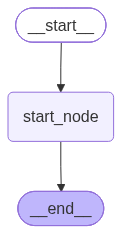

In [13]:
#Now We Will Start Creating Nodes
def start_node(State: State):
    return {"messages": [llm_groq.invoke(State['messages'])]}

#create The Graph
graph=StateGraph(State)

#create Node
graph.add_node("start_node", start_node)

#Create Edges
graph.add_edge(START, "start_node")
graph.add_edge("start_node", END)

graph_builder=graph.compile()

#View the Graph
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [ ]:
response=graph_builder.invoke({'messages':"hello my name is onkar and i love to play football"})
response=graph_builder.invoke({'messages':"hello my name is onkar and i love to play football"})



{'messages': [HumanMessage(content='hello my name is onkar and i love to play football', additional_kwargs={}, response_metadata={}, id='b1769f74-e3f4-4b5b-ba73-63c6b31add36'),
  AIMessage(content='Hey Onkar! Great to meet you. ⚽️ How’s your football game going? Do you have a favorite team or position you love to play?', additional_kwargs={'reasoning_content': 'The user says hello, introduces themselves. We should respond friendly, perhaps ask about football. No disallowed content. Just respond.'}, response_metadata={'token_usage': {'completion_tokens': 68, 'prompt_tokens': 83, 'total_tokens': 151, 'completion_time': 0.144680585, 'completion_tokens_details': {'reasoning_tokens': 27}, 'prompt_time': 0.003951276, 'prompt_tokens_details': None, 'queue_time': 0.427429316, 'total_time': 0.148631861}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_93703442d9', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0fd